# PR09 · Correct time sampling without inventing slice metadata

<!-- paper-first -->
### Research question

**Reading:** [PP01](../../curriculum/papers/processing.md#pp01), [PB01](../../curriculum/papers/measurement.md#pb01). Review the assigned figure or result before starting the lesson.

**Question:** How can different acquisition times within a volume affect a task-response interpretation?

Record a prediction, a source location, and one point you want this lesson to clarify. Ask your AI tutor to distinguish the paper’s evidence from its interpretation.
<!-- /paper-first -->

**Format:** 75–100 minutes for this lesson and its small executable lab, followed by the explicitly labeled upstream practice. Run this notebook from a fresh kernel, top to bottom. Core data are synthetic. Software: NumPy, SciPy, Matplotlib; extra imports are stated in code. This is one stage of a longer processing course, not a replacement for supervised research training.

## Learning objectives

- Translate SliceTiming and TR into actual observation times.
- Interpolate to a declared reference time.
- Recognize edge effects and distinguish temporal interpolation from movement correction.

## Understand the operation

A conventional fMRI volume is assembled from slices acquired at different times. If two slices observe the same varying signal at different offsets within a repetition, they can differ even without noise or motion. Slice-timing correction estimates what each slice’s time course would have been at a chosen reference time. It operates along time, not by moving a slice through anatomical space.

The required acquisition offsets come from metadata. They cannot reliably be inferred from the number of slices, a guessed “interleaved” order, or an assumed vendor convention. Multiband acquisition makes several slices share acquisition times. TR describes the interval between corresponding volumes; it is not the offset between adjacent slice indices. Missing or contradictory timing metadata should be investigated, not fabricated by an assistant.

Interpolation uses a model of the time course. It changes sampled values and can create edge uncertainty because observations beyond the run are missing. It does not recover arbitrarily fast dynamics that were never sampled. The chosen temporal reference also has to agree with subsequent event timing and model conventions. Head motion adds an interaction: moving anatomy may be represented by different slices over time, so no single universal sequence of independently written corrections solves every case. Validated pipelines document their order and assumptions.

The lab uses two perfectly known sinusoidal signals offset by one second. Cubic interpolation brings both to a one-second reference grid over their overlapping domain. We separately reverse the assumed offset to show that valid code can implement the wrong acquisition history.

## Transformation contract

**Input:** slice-specific samples, TR and within-TR offsets. **Output:** estimated samples on one reference-time grid. **Preserved:** declared output sampling schedule. **Changed:** values and temporal dependence. **Unavailable:** actual missing-edge observations; do not claim interpolation created them.


## Read the actual course material

- [Berkeley Psych214: slice-time interpolation](https://github.com/bic-berkeley/psych-214-fall-2016/blob/ec44652addc92091183456fa04fcd41dca0e172e/slice_timing.tpl). CC BY 2.0 website; linked only.
- [fMRIPrep: pipeline details](https://fmriprep.org/en/stable/workflows.html). Official project documentation; linked only.

Read the named topic alongside this lesson; compare its real-image assumptions with our controlled example. These notebooks use original explanations and original code, not copied upstream passages. The source chapter is the place to continue to a complete real-tool practical. External software and downloaded datasets are not silently run by this notebook.


## Predict, then ask your AI assistant

Use Goose with your installed Ollama model, or ChatGPT. The model is a tutor and code author; the local Python runtime performs these calculations. Paste:

> List acquisition times for the first three volumes of both slices. Use those times to interpolate onto a1-second reference offset, and test only a declared interior interval. Explain the bad-offset example without silently changing the underlying signal. Return at most 20 executable lines per cell, show units and array shapes, and preserve the original. Explain the prediction before running. If an assertion fails, diagnose the disagreement rather than deleting the check.

Write your prediction before executing the reference cells below.


In [1]:
import numpy as np
from scipy.interpolate import CubicSpline
import matplotlib.pyplot as plt
TR=2.; n=120; offsets=np.array([0.,1.])
base=np.arange(n)*TR; reference_time=base+1
signal=lambda t: np.sin(2*np.pi*.04*t)
samples=np.column_stack([signal(base+off) for off in offsets])
corrected=np.column_stack([CubicSpline(base+off,samples[:,j])(reference_time)
                           for j,off in enumerate(offsets)])
wrong=CubicSpline(base-1,samples[:,1])(reference_time)
interior=slice(3,-3); target=signal(reference_time)
raw_mse=np.mean((samples[interior,0]-target[interior])**2)
correct_mse=np.mean((corrected[interior,0]-target[interior])**2)
wrong_mse=np.mean((wrong[interior]-target[interior])**2)
print('raw/correct/wrong timing MSE:',raw_mse,correct_mse,wrong_mse)
assert correct_mse<raw_mse/100 and wrong_mse>correct_mse*100


raw/correct/wrong timing MSE: 0.031052744055596774 1.578036760897925e-08 0.12303686605561612


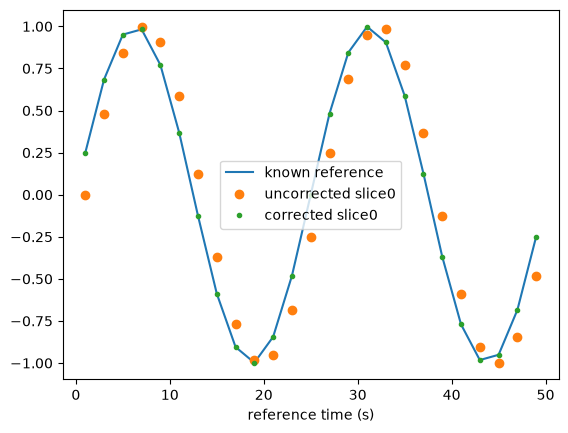

Original acquisition offsets: [0. 1.] seconds; reference offset:1 second


In [2]:
plt.plot(reference_time[:25],target[:25],label='known reference')
plt.plot(reference_time[:25],samples[:25,0],'o',label='uncorrected slice0')
plt.plot(reference_time[:25],corrected[:25,0],'.',label='corrected slice0')
plt.xlabel('reference time (s)'); plt.legend(); plt.show()
assert offsets.min()>=0 and offsets.max()<TR
print('Original acquisition offsets:',offsets,'seconds; reference offset:1 second')


## Check and explain

Correct interpolation reduces central MSE by more than100-fold. The deliberately wrong timing increases error. The exclusion of edge samples from the assertion does not certify the edges; inspect and report their limitations separately.

## Deliberately wrong method

Assuming slice index equals acquisition time, changing TR to match a desired plot, or treating slice timing as a spatial shift all violate the input contract. The wrong branch illustrates an incorrect offset rather than a failed optimizer.

## Transfer to an actual dataset or tool — guided assignment

Read the actual Berkeley slice-timing chapter and inspect the SliceTiming array for a real BIDS run selected by a mentor. Count slices and repeated offsets, verify units, then find the reference time used in the chosen fMRIPrep/SPM/FSL processing. Document the event-time convention for the later GLM. If the dataset lacks timing, record what the pipeline skipped; do not manufacture an interleave schedule. Full real-run correction is an external pipeline exercise.

**Submit:** a transformation card, one labeled figure or numerical result, the failed-method diagnosis, and the upstream-practice evidence. If the external exercise has not been run, mark it **not executed** and state the missing software/data; do not convert a proposed command into a claimed result.

## Exit questions and answer key

1. Why can multiband timing contain repeated values? **Answer:** several slices can be acquired together.
2. Does correction add temporal resolution? **Answer:** it estimates a common reference from sampled observations; it does not create independently acquired high-frequency information.


### Return to the research question

Revisit [PP01](../../curriculum/papers/processing.md#pp01), [PB01](../../curriculum/papers/measurement.md#pb01) and your initial prediction. In your [evidence ledger](../../curriculum/coursework/EVIDENCE_LEDGER.md):

1. Cite one output or diagnostic from this lesson and explain the transformation it demonstrates.
2. Revise one claim or question from the paper, with a figure or section locator. Which part of the published result remains open after this exercise?
3. Ask AI to propose a next check. Accept, revise or reject it with a scientific reason. Then explain your decision aloud without reading the AI response.

Include this entry in the A2 portfolio when relevant.
